In [1]:
import torch
from dinosaw.wrappers import ModelTypes, MODEL_NAMES, get_models
from dinosaw.utils import do_2D_pca, get_features

import numpy as np
from PIL import Image

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda:0'
half = False
torch.cuda.empty_cache()

/home/ronan/dino-saw/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
enabled_models: tuple[ModelTypes, ...] = ('dinov2_s', 'alibi_coco_dinov2_s',)
models = get_models(enabled_models, DEVICE, True, "../../models/checkpoints", "../../models/dinov3")

2026-08-11 12:47:29 | I | factory.py                 : 152 | Building wrapper 'dinov2_s' on device cuda:0
2026-08-11 12:47:29 | I | factory.py                 : 131 | Building backbone with config: BackboneConfig(backbone_type='timm', model_arch='dinov2_s', pretrained=True, checkpoint_path=None, model_conf_path='../../models/dinov3', stride=None, remove_pos_embed=False, add_flash_attn=False, dynamic_img_size=True, dynamic_img_pad=False, modifications=[], dtype=torch.float32)


2026-08-11 12:47:29 | I | wrapper.py                 :  48 | Initialized PretrainedViTWrapper - name: '', arch: 'None', device: cuda:0, stride: (14, 14), patch_size: (14, 14), embed_dim: 384, num_blocks: 12
2026-08-11 12:47:29 | I | factory.py                 : 152 | Building wrapper 'alibi_coco_dinov2_s' on device cuda:0
2026-08-11 12:47:29 | I | factory.py                 : 131 | Building backbone with config: BackboneConfig(backbone_type='timm', model_arch='dinov2_s', pretrained=False, checkpoint_path='../../models/checkpoints/trained/alibi_coco_dv2_vits14_reg4.pth', model_conf_path='../../models/dinov3', stride=None, remove_pos_embed=True, add_flash_attn=False, dynamic_img_size=True, dynamic_img_pad=False, modifications=[functools.partial(<function add_alibi at 0x7f71c6f3a160>, slope_type='constant', n_reg_tokens=4, metric='euclidean', normalize=True, wrap=True, add_cls=True, jitter_mag=0.0)], dtype=torch.float32)
2026-08-11 12:47:30 | I | modifications.py           :  47 | Removed

In [3]:
SF = 0.5

img_fname = "../../tests/default_image.jpg"

_img = Image.open(f"{img_fname}").convert("RGB")
_img = _img.resize((int(SF * _img.width), int(SF * _img.height)), Image.BILINEAR)

In [4]:
features = {}
features_reduced = {}

In [5]:
for model_key in enabled_models:
    model = models[model_key]
    feats = get_features(model, _img, False)
    features[model_key] = feats

2026-08-11 12:47:30 | I | wrapper.py                 :  92 | Processing image, size: [512, 448]
2026-08-11 12:47:30 | I | wrapper.py                 : 192 | Forward Features: x: [1,3,448,504] -> f: [1,384,32,36]
2026-08-11 12:47:30 | I | wrapper.py                 :  92 | Processing image, size: [512, 448]
2026-08-11 12:47:30 | I | wrapper.py                 : 192 | Forward Features: x: [1,3,448,504] -> f: [1,384,32,36]


In [6]:
for model_key in enabled_models:
    feats = features[model_key]
    features_reduced[model_key] = do_2D_pca(feats, 9, pre_norm='std', post_norm='minmax')

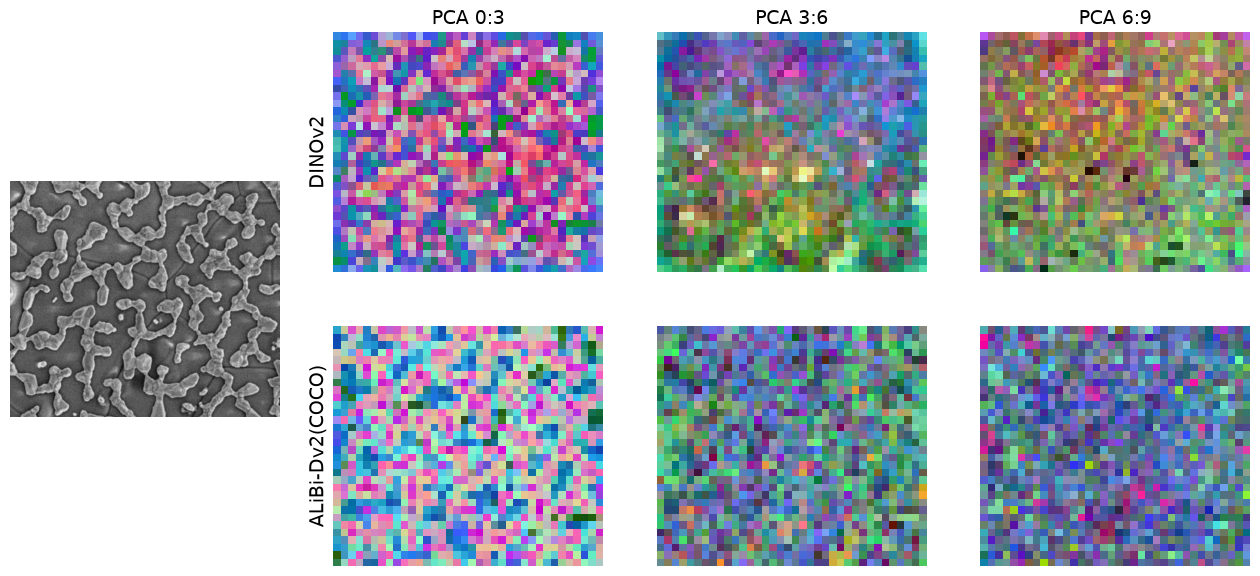

In [7]:
def hide_axes(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

sf = _img.width / _img.height
L = 3.5
FS = 14
w, h = L * sf, L
nrows, ncols = len(enabled_models), 4

fig = plt.figure(figsize=(w * ncols, h * nrows))
gs = GridSpec(nrows, ncols, figure=fig)

img_ax = fig.add_subplot(gs[:, 0])
img_ax.imshow(_img)
hide_axes(img_ax)



for i, model_key in enumerate(enabled_models):
    for pca_idx in (0, 1, 2):
        feats_red = features_reduced[model_key]
        idx_0, idx_1 = pca_idx * 3, (pca_idx + 1) * 3
        components = feats_red[:, :, (pca_idx * 3):((pca_idx + 1) * 3)]

        ax = fig.add_subplot(gs[i, 1 + pca_idx])

        ax.imshow(components)
        hide_axes(ax)
        if pca_idx == 0:
            ax.set_ylabel(MODEL_NAMES[model_key], fontsize=FS)

        if i == 0:
            ax.set_title(f"PCA {idx_0}:{idx_1}", fontsize=FS)